# Analisi, Verifica e Data Augmentation per Dataset Multiclasse

In [1]:
import pandas as pd
from pathlib import Path

# Definizione dei percorsi
DATA_DIR = Path('../data/labelled')
INPUT_FILE = DATA_DIR / 'multiclass2.csv'
OUTPUT_FILE = DATA_DIR / 'multiclass2_augmented.csv'

# Caricamento dataset
# Utilizziamo low_memory=False nel caso ci siano campi misti
df = pd.read_csv(INPUT_FILE, low_memory=False)

print(f"Caricate {len(df)} righe originali.")
df.head(3)

Caricate 6483 righe originali.


,Descrizione,Label
0,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,Robotics and Industry
1,messa a punto di un sistema di Big Data Analyt...,Enterprise AI
2,Implementazione sistemi di AI (artificial inte...,Enterprise AI


## Analisi della Distribuzione delle Label
Visualizziamo il bilanciamento delle classi per comprendere quali necessitano maggiormente di augmentation. Dato che il dataset ruota attorno a campi di applicazione dell'AI, alcune categorie più specifiche potrebbero essere sotto-rappresentate.

C:\Users\Gabs\AppData\Local\Temp\ipykernel_8488\1455337369.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Label', data=df, order=df['Label'].value_counts().index, palette='viridis')


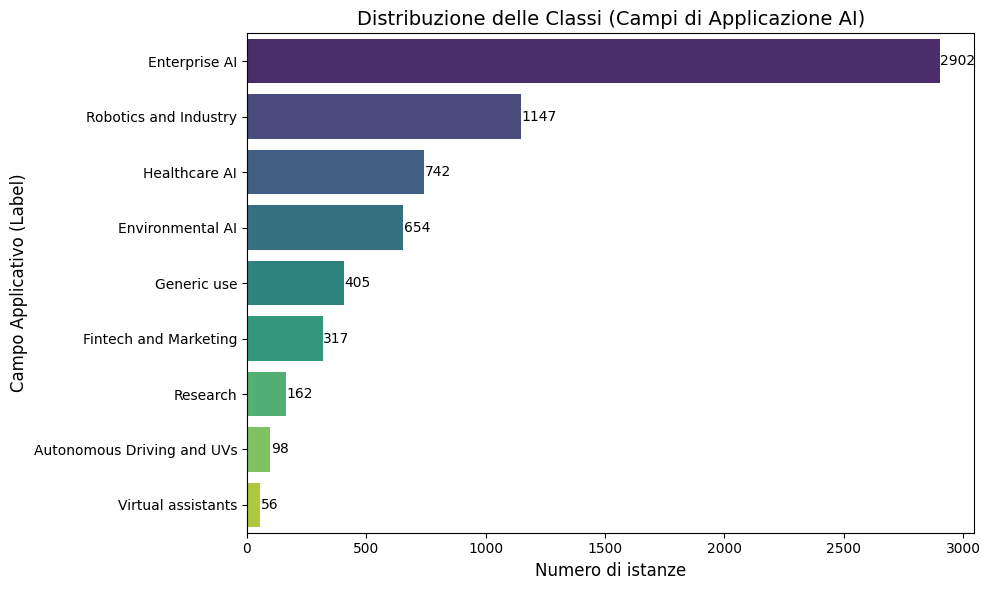

Distribuzione numerica:


Label
Enterprise AI                 2902
Robotics and Industry         1147
Healthcare AI                  742
Environmental AI               654
Generic use                    405
Fintech and Marketing          317
Research                       162
Autonomous Driving and UVs      98
Virtual assistants              56
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Usando sns.countplot per le counts 
ax = sns.countplot(y='Label', data=df, order=df['Label'].value_counts().index, palette='viridis')

plt.title('Distribuzione delle Classi (Campi di Applicazione AI)', fontsize=14)
plt.xlabel('Numero di istanze', fontsize=12)
plt.ylabel('Campo Applicativo (Label)', fontsize=12)
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width() + 2, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center')

plt.show()

# Stampa i valori esatti
print("Distribuzione numerica:")
display(df['Label'].value_counts())

## Ottimizzazione della Data Augmentation per Campi AI (Italiano)
La terminologia relativa ai progetti di Intelligenza Artificiale è spesso ibrida (Italiano-Inglese) e molto legata al contesto. Approcci casuali come *Random Swap* o *Deletion* rovinerebbero il senso delle descrizioni, generando rumore. 
L'approccio inserito utilizza **Back Translation** (IT -> EN -> IT) o Embeddings Contestualizzati (M-BERT). Questo mantiene inalterate le "keyword" specifiche del dominio AI modificando invece le parole di contorno o generando sinonimi calzanti, consentendo al nostro dataset `multiclass1.csv` di ingrandirsi tutelando la qualità.

In [3]:
# Installazione rapida dei pacchetti (toglile il commento se non possiedi le librerie installate)
# !pip install transformers torch sacremoses pandas sklearn tqdm

import pandas as pd
from tqdm import tqdm
import torch
from transformers import MarianMTModel, MarianTokenizer

# Verifichiamo disponibilità device. 
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Device utilizzato per l'augmentation: {device}")

# STRATEGIA 2: Back Translation (IT -> EN -> IT) pura usando HuggingFace Transformers (Senza NLPaug)
# Evita i problemi di incompatibilità tra librerie obsolete (es. _convert_token_to_id mancante in nlpaug)
print("Caricamento modelli di traduzione (MarianMT) per Back-Translation...")

model_name_it_en = "Helsinki-NLP/opus-mt-it-en"
model_name_en_it = "Helsinki-NLP/opus-mt-en-it"

try:
    tokenizer_it_en = MarianTokenizer.from_pretrained(model_name_it_en)
    model_it_en = MarianMTModel.from_pretrained(model_name_it_en).to(device)

    tokenizer_en_it = MarianTokenizer.from_pretrained(model_name_en_it)
    model_en_it = MarianMTModel.from_pretrained(model_name_en_it).to(device)
    print("Modelli di traduzione caricati con successo.")
    translation_available = True
except Exception as e:
    print(f"Errore nel caricamento dei modelli di traduzione: {e}")
    translation_available = False

def perform_back_translation(text):
    """Traduce il testo da IT a EN e poi di nuovo da EN a IT per ottenere una parafrasi coerente."""
    if not translation_available:
        return text
        
    # IT -> EN
    it_encoded = tokenizer_it_en(text, return_tensors="pt", padding=True, truncation=True).to(device)
    en_translated = model_it_en.generate(**it_encoded)
    en_text = [tokenizer_it_en.decode(t, skip_special_tokens=True) for t in en_translated][0]
    
    # EN -> IT
    en_encoded = tokenizer_en_it(en_text, return_tensors="pt", padding=True, truncation=True).to(device)
    it_translated = model_en_it.generate(**en_encoded)
    aug_text = [tokenizer_en_it.decode(t, skip_special_tokens=True) for t in it_translated][0]
    
    return aug_text

def augment_minority_classes(df, target_col='Label', text_col='Descrizione', k_multiplier=2, min_count_threshold=100):
    """
    Esegue data augmentation tramite Back-Translation. 
    """
    df_augmented = df.copy()
    label_counts = df[target_col].value_counts()
    
    minority_classes = label_counts[label_counts < min_count_threshold].index.tolist()
    print(f"Classi di minoranza da incrementare: {minority_classes}")
    
    new_rows = []
    
    # Processiamo solo i casi per l'augmentation
    for label in minority_classes:
        df_minority = df[df[target_col] == label]
        
        for idx, row in tqdm(df_minority.iterrows(), total=len(df_minority), desc=f"Augmenting {label}"):
            original_text = str(row[text_col])
            
            # Dal momento che la BackTranslation tende a essere deterministica con greedy search,
            # aggiungeremo variazioni eseguendolo 1 sola volta in modo sicuro e affidabile
            # per riempire il pool di dati. In un iter reale se k > 1 suggeriamo usare parametri di sampling
            # come do_sample=True, temperature=0.7 in generate(). Per semplicità, qui facciamo 1 singola passata robusta.
            
            for _ in range(1): # Per la translation pura facciamo 1 versione parafrasata per record. 
                augmented_text = perform_back_translation(original_text)
                    
                if augmented_text and augmented_text != original_text:
                    new_row = row.copy()
                    new_row[text_col] = augmented_text
                    
                    # Inserisci una label / flag che traccia i dati generati, se utile
                    new_row['Is_Augmented'] = True 
                    new_rows.append(new_row)
                        
    if new_rows:
        df_new_data = pd.DataFrame(new_rows)
        if 'Is_Augmented' not in df_augmented.columns:
            df_augmented['Is_Augmented'] = False
            
        df_augmented = pd.concat([df_augmented, df_new_data], ignore_index=True)
        print(f"Data Augmentation Completata. Aggiunte {len(new_rows)} nuove righe.")
    else:
        print("Nessun nuovo dato generato.")
        
    return df_augmented

# ----- ESEMPIO DI ESECUZIONE -----
# 
# df_augmented = augment_minority_classes(
#     df, 
#     target_col='Label', 
#     text_col='Descrizione', 
#     min_count_threshold=200 
# )
#
# print(df_augmented['Label'].value_counts())
# # df_augmented.to_csv(OUTPUT_FILE, index=False)

c:\Users\Gabs\Desktop\AI nelle Imprese\open-data-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device utilizzato per l'augmentation: cuda
Caricamento modelli di traduzione (MarianMT) per Back-Translation...


Loading weights: 100%|██████████| 258/258 [00:00<00:00, 24242.36it/s]


Modelli di traduzione caricati con successo.


In [4]:
# ----- ESEMPIO DI ESECUZIONE -----
# 
df_augmented = augment_minority_classes(df,'Label', 'Descrizione', min_count_threshold=200)

print(df_augmented['Label'].value_counts())
df_augmented.to_csv(OUTPUT_FILE, index=False)

Classi di minoranza da incrementare: ['Research', 'Autonomous Driving and UVs', 'Virtual assistants']


Augmenting Virtual assistants: 100%|██████████| 56/56 [02:28<00:00,  2.65s/it]

Data Augmentation Completata. Aggiunte 312 nuove righe.
Label
Enterprise AI                 2902
Robotics and Industry         1147
Healthcare AI                  742
Environmental AI               654
Generic use                    405
Research                       322
Fintech and Marketing          317
Autonomous Driving and UVs     195
Virtual assistants             111
Name: count, dtype: int64
